# Above-Uniform-Share CSD LightEval Results

Visualize the `above_uniform_share` sweep:

- EAGLE baseline: `vanilla`
- Static CSD table: `csd_ratio_table_static`
- Dynamic CSD update respecting the prob-ratio gate
- Dynamic CSD update ignoring the prob-ratio gate

The notebook defaults to the newest `benchmark/csd/runs/lighteval_csd_above_uniform_share/*/results/csd_above_uniform_share.jsonl`. Override with `RESULT_FILE=/path/to/file.jsonl`.

In [35]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "benchmark" / "csd").exists():
    REPO_ROOT = Path("/root/sglang")

def latest_result_file() -> Path:
    candidates = sorted(
        (REPO_ROOT / "benchmark/csd/runs/lighteval_csd_above_uniform_share").glob("*/results/csd_above_uniform_share.jsonl"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError("No csd_above_uniform_share.jsonl result files found.")
    return candidates[0]

RESULT_FILE = Path(os.environ.get("RESULT_FILE", latest_result_file()))
RESULT_FILE

PosixPath('/root/sglang/benchmark/csd/runs/lighteval_csd_above_uniform_share/20260605_182153/results/csd_above_uniform_share.jsonl')

In [36]:
def short_task(task: str) -> str:
    if task.startswith("lcb:"):
        return "lcb"
    if task.startswith("math_500"):
        return "math500"
    return task.split("|")[0]

def method_from_tag(tag: str, task: str) -> str:
    slug = short_task(task)
    marker = f"_{slug}_"
    if marker in tag:
        return tag.split(marker, 1)[0]
    for fallback in ["_lcb_", "_aime25_", "_math500_", "_gsm8k_"]:
        if fallback in tag:
            return tag.split(fallback, 1)[0]
    return tag

def variant_from_row(row: dict) -> str:
    other = row.get("other") or {}
    tag = other.get("run_tag", "")
    csd = other.get("csd") or {}
    method = method_from_tag(tag, row.get("task", ""))
    if method == "vanilla":
        return "vanilla"
    if method == "csd_ratio_table_static":
        return "static"
    if method == "csd_ratio_table" and csd.get("dynamic_update_ignore_prob_ratio"):
        return "dynamic_ignore"
    if method == "csd_ratio_table" and csd.get("dynamic_update"):
        return "dynamic_respect"
    return method

def min_count_from_row(row: dict):
    csd = (row.get("other") or {}).get("csd") or {}
    if csd.get("freq_threshold") is not None:
        return int(csd["freq_threshold"])
    tag = (row.get("other") or {}).get("run_tag", "")
    m = re.search(r"mincount(\d+)", tag)
    return int(m.group(1)) if m else None

records = []
with RESULT_FILE.open() as f:
    for line in f:
        if not line.strip():
            continue
        row = json.loads(line)
        other = row.get("other") or {}
        csd = other.get("csd") or {}
        perf = other.get("performance") or {}
        spec = other.get("speculative_metrics") or {}
        server = other.get("server_config") or {}
        task = row.get("task")
        tag = other.get("run_tag", "")
        lookup = row.get("csd_lookup_hit_ct") or 0
        forced = row.get("csd_forced_accept_ct") or 0
        records.append({
            "task": task,
            "task_short": short_task(task),
            "variant": variant_from_row(row),
            "method": method_from_tag(tag, task),
            "min_count": min_count_from_row(row),
            "accuracy": row.get("accuracy"),
            "latency": row.get("latency"),
            "throughput": row.get("throughput"),
            "request_throughput": perf.get("request_throughput"),
            "spec_success_rate": row.get("spec_success_rate"),
            "accept_length": row.get("aggregate_accept_length"),
            "spec_saved_ratio": row.get("spec_output_token_saved_ratio"),
            "spec_verify_ct": row.get("spec_verify_ct"),
            "csd_lookup_hit_ct": lookup,
            "csd_forced_accept_ct": forced,
            "csd_force_per_lookup": forced / lookup if lookup else 0.0,
            "csd_delta_pair_ct": row.get("csd_delta_pair_ct") or 0,
            "num_requests": row.get("num_requests"),
            "avg_prompt_tokens": row.get("avg_prompt_tokens"),
            "avg_completion_tokens": row.get("avg_completion_tokens"),
            "strategy": csd.get("key_selection_strategy") or server.get("speculative_csd_key_selection_strategy"),
            "dynamic_update": bool(csd.get("dynamic_update")),
            "ignore_prob_ratio": bool(csd.get("dynamic_update_ignore_prob_ratio")),
            "run_tag": tag,
        })

df = pd.DataFrame(records)
variant_order = ["vanilla", "static", "dynamic_respect", "dynamic_ignore"]
task_order = ["lcb", "aime25", "math500", "gsm8k"]
df["variant"] = pd.Categorical(df["variant"], categories=variant_order, ordered=True)
df["task_short"] = pd.Categorical(df["task_short"], categories=task_order, ordered=True)
df = df.sort_values(["task_short", "variant", "min_count"], na_position="first").reset_index(drop=True)

print("RESULT_FILE:", RESULT_FILE)
print("rows:", len(df))
display(df.groupby(["task_short", "variant"], observed=False).size().unstack(fill_value=0))
display(df.head())

RESULT_FILE: /root/sglang/benchmark/csd/runs/lighteval_csd_above_uniform_share/20260605_182153/results/csd_above_uniform_share.jsonl
rows: 64


variant,vanilla,static,dynamic_respect,dynamic_ignore
task_short,,,,
lcb,1,5,5,5
aime25,1,5,5,5
math500,1,5,5,5
gsm8k,1,5,5,5


,task,task_short,variant,method,min_count,accuracy,latency,throughput,request_throughput,spec_success_rate,accept_length,spec_saved_ratio,spec_verify_ct,csd_lookup_hit_ct,csd_forced_accept_ct,csd_force_per_lookup,csd_delta_pair_ct,num_requests,avg_prompt_tokens,avg_completion_tokens,strategy,dynamic_update,ignore_prob_ratio,run_tag
0,lcb:codegeneration_v6|0,lcb,vanilla,vanilla,NaN,0.714286,2360.219,2497.427,0.074,0.4764,3.3821,0.7043,1742840,0,0,0.000000,0,175,596.017,33682.709,frequency,False,False,vanilla_lcb_recommended_steps5_topk1_draft5_ke...
1,lcb:codegeneration_v6|0,lcb,static,csd_ratio_table_static,2.0,0.737143,1752.730,3099.987,0.100,0.6158,4.0788,0.7548,1332106,53697440,35441467,0.660022,0,175,596.017,31048.223,above_uniform_share,False,False,csd_ratio_table_static_lcb_recommended_steps5_...
2,lcb:codegeneration_v6|0,lcb,static,csd_ratio_table_static,3.0,0.748571,1852.654,2982.711,0.094,0.6092,4.0460,0.7529,1365761,51060107,33696757,0.659943,0,175,596.017,31576.754,above_uniform_share,False,False,csd_ratio_table_static_lcb_recommended_steps5_...
3,lcb:codegeneration_v6|0,lcb,static,csd_ratio_table_static,4.0,0.737143,1796.073,3048.085,0.097,0.6037,4.0187,0.7512,1362273,49496301,32742397,0.661512,0,175,596.017,31283.331,above_uniform_share,False,False,csd_ratio_table_static_lcb_recommended_steps5_...
4,lcb:codegeneration_v6|0,lcb,static,csd_ratio_table_static,5.0,0.771429,1901.767,2937.057,0.092,0.5976,3.9881,0.7493,1400582,48298569,31986007,0.662256,0,175,596.017,31917.703,above_uniform_share,False,False,csd_ratio_table_static_lcb_recommended_steps5_...


## Add Vanilla Deltas

Deltas are computed per task against the same-run `vanilla` EAGLE baseline.

In [37]:
metrics = ["accuracy", "throughput", "spec_success_rate", "accept_length", "spec_saved_ratio"]

# Some pandas versions preserve category dtype through Series.map when the
# key column is categorical. Use an explicit string key and numeric casts so
# delta arithmetic is stable across notebook environments.
task_key = df["task_short"].astype(str)
for metric in metrics:
    df[metric] = pd.to_numeric(df[metric], errors="coerce")

baseline = (
    df[df["variant"] == "vanilla"]
    .assign(task_key=lambda x: x["task_short"].astype(str))
    .set_index("task_key")[metrics]
)

for metric in metrics:
    df[f"{metric}_vanilla"] = pd.to_numeric(task_key.map(baseline[metric]), errors="coerce")
    df[f"{metric}_delta"] = df[metric] - df[f"{metric}_vanilla"]

df["throughput_speedup_vs_vanilla"] = df["throughput"] / df["throughput_vanilla"]

summary_cols = [
    "task_short", "variant", "min_count", "accuracy", "accuracy_delta",
    "spec_success_rate", "spec_success_rate_delta", "throughput", "throughput_speedup_vs_vanilla",
    "accept_length", "spec_saved_ratio", "csd_lookup_hit_ct", "csd_forced_accept_ct", "csd_force_per_lookup",
]
display(df[summary_cols])

,task_short,variant,min_count,accuracy,accuracy_delta,spec_success_rate,spec_success_rate_delta,throughput,throughput_speedup_vs_vanilla,accept_length,spec_saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct,csd_force_per_lookup
0,lcb,vanilla,NaN,0.714286,0.000000,0.4764,0.0000,2497.427,1.000000,3.3821,0.7043,0,0,0.000000
1,lcb,static,2.0,0.737143,0.022857,0.6158,0.1394,3099.987,1.241272,4.0788,0.7548,53697440,35441467,0.660022
2,lcb,static,3.0,0.748571,0.034285,0.6092,0.1328,2982.711,1.194314,4.0460,0.7529,51060107,33696757,0.659943
3,lcb,static,4.0,0.737143,0.022857,0.6037,0.1273,3048.085,1.220490,4.0187,0.7512,49496301,32742397,0.661512
4,lcb,static,5.0,0.771429,0.057143,0.5976,0.1212,2937.057,1.176033,3.9881,0.7493,48298569,31986007,0.662256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,gsm8k,dynamic_ignore,2.0,0.905989,-0.000759,0.7007,0.1129,3997.643,0.912555,4.5036,0.7781,110304140,53187486,0.482189
60,gsm8k,dynamic_ignore,3.0,0.909022,0.002274,0.6949,0.1071,4437.905,1.013055,4.4743,0.7767,103493456,50181476,0.484876
61,gsm8k,dynamic_ignore,4.0,0.906748,0.000000,0.6904,0.1026,4457.110,1.017439,4.4518,0.7756,100611802,49100645,0.488021
62,gsm8k,dynamic_ignore,5.0,0.918120,0.011372,0.6861,0.0983,4434.629,1.012308,4.4304,0.7745,94609358,45484094,0.480757


## Best Runs By Task

Separate best-by-accuracy and best-by-throughput views. Throughput-only best can hide accuracy regressions, so use both.

In [38]:
non_vanilla = df[df["variant"] != "vanilla"].copy()
best_acc = non_vanilla.loc[non_vanilla.groupby("task_short", observed=False)["accuracy"].idxmax(), summary_cols]
best_thr = non_vanilla.loc[non_vanilla.groupby("task_short", observed=False)["throughput"].idxmax(), summary_cols]

print("Best CSD run by accuracy")
display(best_acc)
print("Best CSD run by throughput")
display(best_thr)

Best CSD run by accuracy


,task_short,variant,min_count,accuracy,accuracy_delta,spec_success_rate,spec_success_rate_delta,throughput,throughput_speedup_vs_vanilla,accept_length,spec_saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct,csd_force_per_lookup
4,lcb,static,5.0,0.771429,0.057143,0.5976,0.1212,2937.057,1.176033,3.9881,0.7493,48298569,31986007,0.662256
19,aime25,static,4.0,0.933333,0.033333,0.6781,0.1302,2582.866,1.210634,4.3905,0.7722,1251974,741945,0.592620
45,math500,dynamic_ignore,4.0,0.854000,0.020000,0.7456,0.1841,4315.750,1.038302,4.7282,0.7885,109552586,64960179,0.592959
51,gsm8k,static,4.0,0.921152,0.014404,0.6618,0.0740,4599.131,1.049859,4.3092,0.7681,74646763,35884504,0.480724


Best CSD run by throughput


,task_short,variant,min_count,accuracy,accuracy_delta,spec_success_rate,spec_success_rate_delta,throughput,throughput_speedup_vs_vanilla,accept_length,spec_saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct,csd_force_per_lookup
10,lcb,dynamic_respect,6.0,0.731429,0.017143,0.6872,0.2108,3231.660,1.293996,4.4361,0.7746,66326484,44427869,0.669836
28,aime25,dynamic_ignore,3.0,0.900000,0.000000,0.7272,0.1793,2712.852,1.271561,4.6361,0.7843,1444535,855623,0.592317
35,math500,static,4.0,0.836000,0.002000,0.6877,0.1262,4728.631,1.137635,4.4386,0.7747,83415822,49618408,0.594832
51,gsm8k,static,4.0,0.921152,0.014404,0.6618,0.0740,4599.131,1.049859,4.3092,0.7681,74646763,35884504,0.480724


## Plot Helpers

In [39]:
colors = {
    "static": "tab:blue",
    "dynamic_respect": "tab:orange",
    "dynamic_ignore": "tab:green",
}
MIN_COUNT_TICKS = [2, 3, 4, 5, 6]


def plot_metric_grid(metric: str, ylabel: str, baseline_metric: str | None = None, include_zero_line: bool = False):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.ravel()
    for ax, task in zip(axes, task_order):
        task_df = df[(df["task_short"].astype(str) == task) & (df["variant"].astype(str) != "vanilla")]
        for variant in ["static", "dynamic_respect", "dynamic_ignore"]:
            sub = task_df[task_df["variant"].astype(str) == variant].sort_values("min_count")
            ax.plot(
                sub["min_count"],
                sub[metric],
                marker="o",
                markersize=6,
                linewidth=1.8,
                label=variant,
                color=colors[variant],
            )
            # Label every point with its min_count so the min_count=6 endpoint is explicit.
            for _, row in sub.iterrows():
                ax.annotate(
                    str(int(row["min_count"])),
                    (row["min_count"], row[metric]),
                    textcoords="offset points",
                    xytext=(0, 6),
                    ha="center",
                    fontsize=8,
                    color=colors[variant],
                )
        if baseline_metric is not None:
            base = df[(df["task_short"].astype(str) == task) & (df["variant"].astype(str) == "vanilla")][baseline_metric]
            if len(base):
                ax.axhline(base.iloc[0], color="black", linestyle="--", linewidth=1, label="vanilla")
        if include_zero_line:
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(task)
        ax.set_xlabel("min_count")
        ax.set_ylabel(ylabel)
        ax.set_xticks(MIN_COUNT_TICKS)
        ax.grid(True, alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig


def heatmap_metric(metric: str, title: str):
    variants = ["static", "dynamic_respect", "dynamic_ignore"]
    fig, axes = plt.subplots(1, len(variants), figsize=(16, 4), sharey=True)
    for ax, variant in zip(axes, variants):
        pivot = df[df["variant"].astype(str) == variant].pivot_table(
            index="task_short", columns="min_count", values=metric, observed=False
        ).reindex(task_order)
        pivot = pivot.reindex(columns=MIN_COUNT_TICKS)
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_title(variant)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([int(x) for x in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("min_count")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.values[i, j]
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    fig.tight_layout()
    return fig



## Accuracy

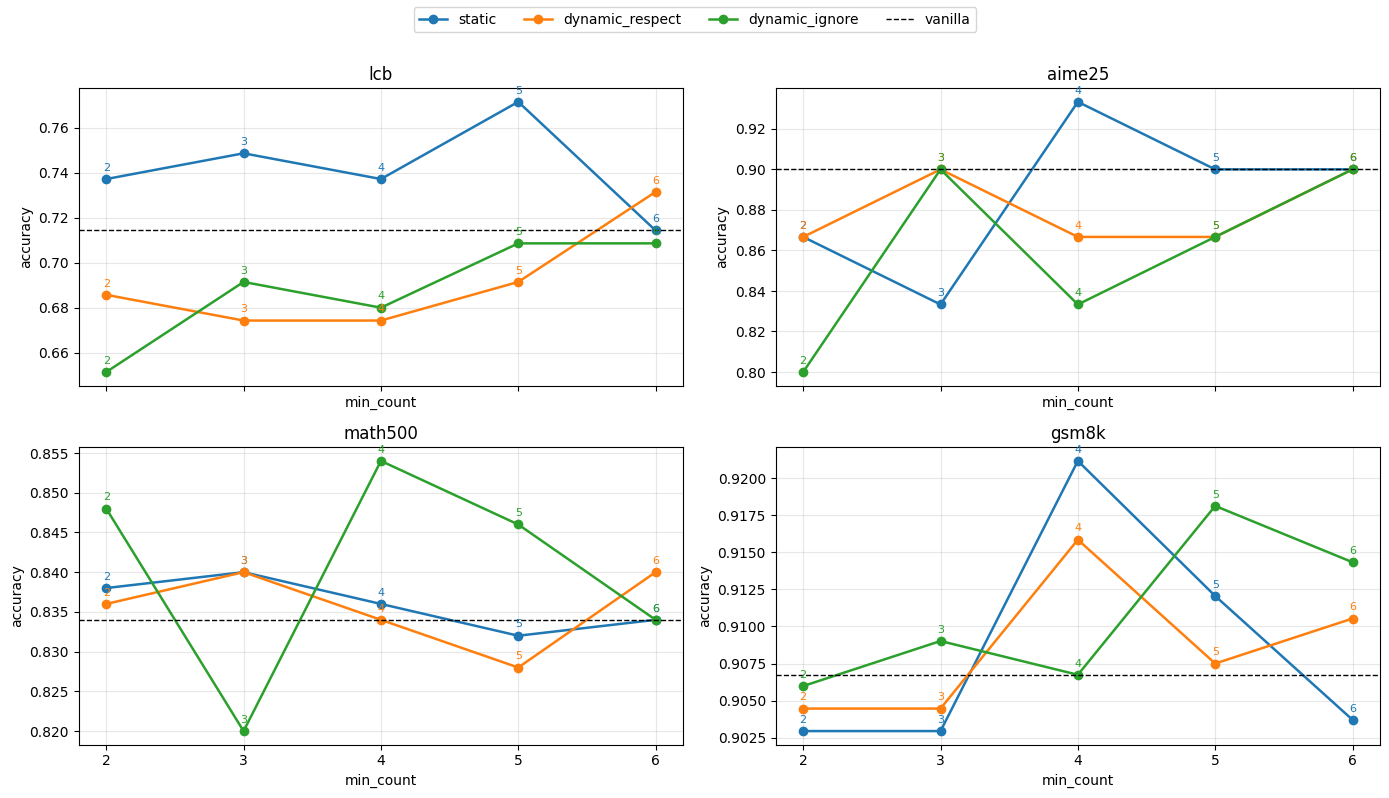

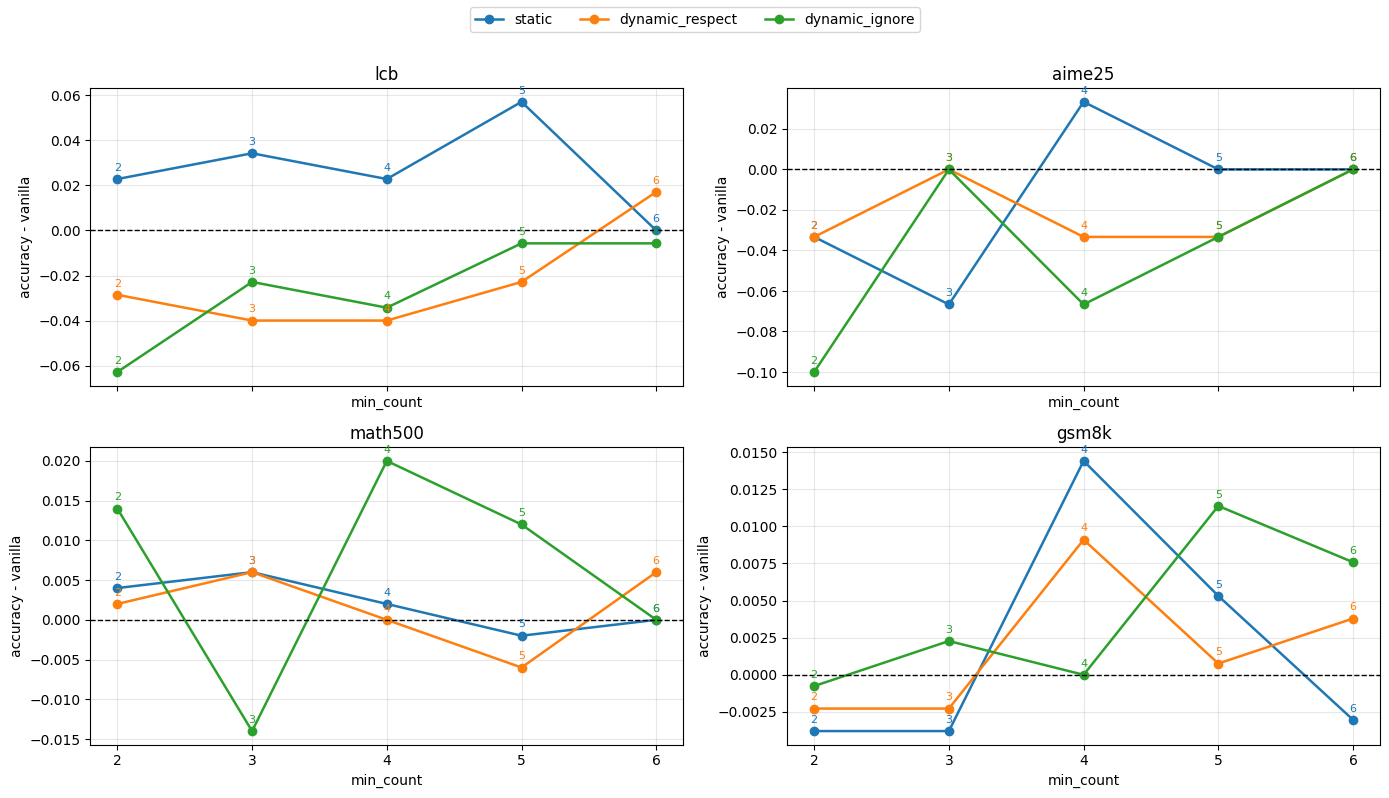

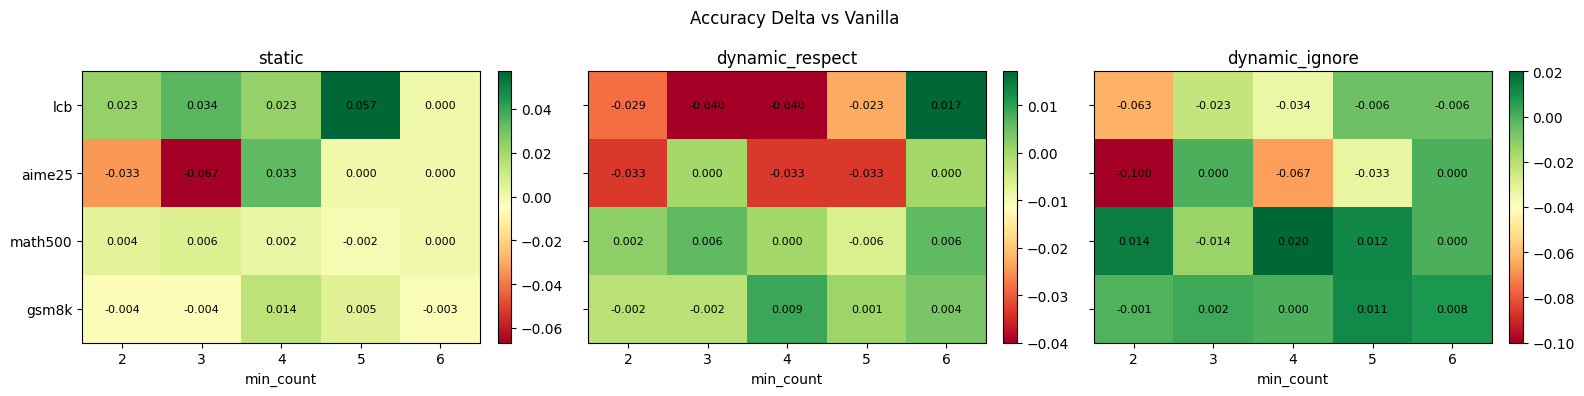

In [40]:
plot_metric_grid("accuracy", "accuracy", baseline_metric="accuracy")
plt.show()

plot_metric_grid("accuracy_delta", "accuracy - vanilla", include_zero_line=True)
plt.show()

heatmap_metric("accuracy_delta", "Accuracy Delta vs Vanilla")
plt.show()

## Speculative Metrics

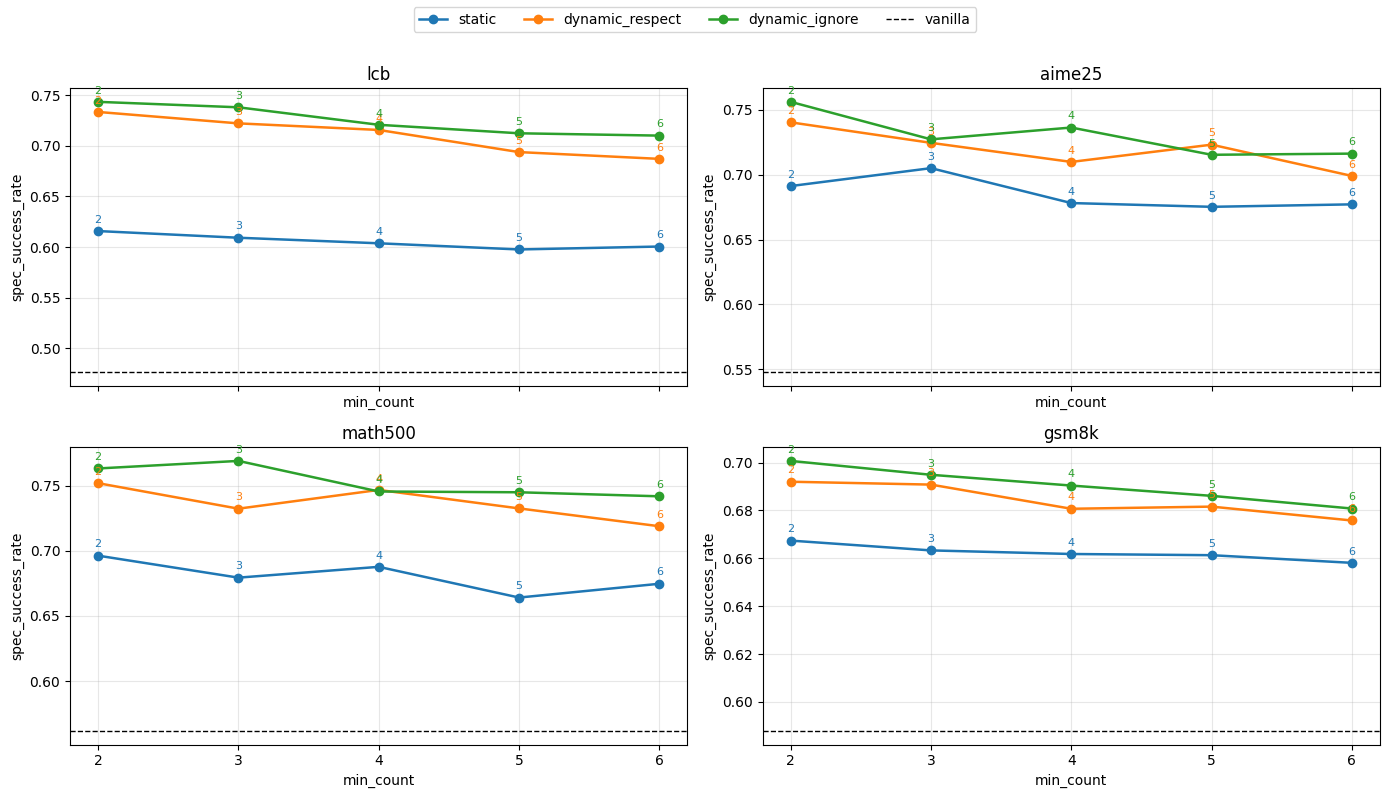

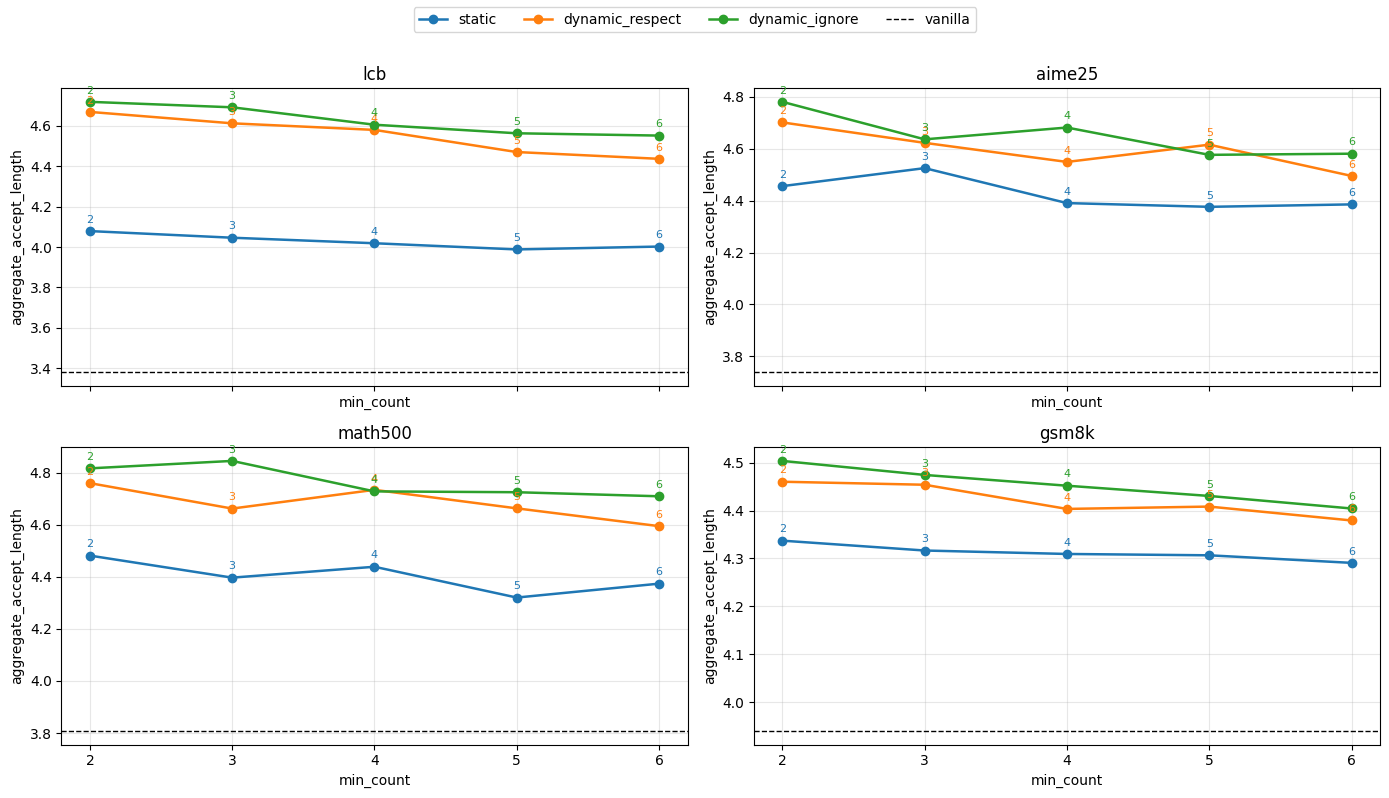

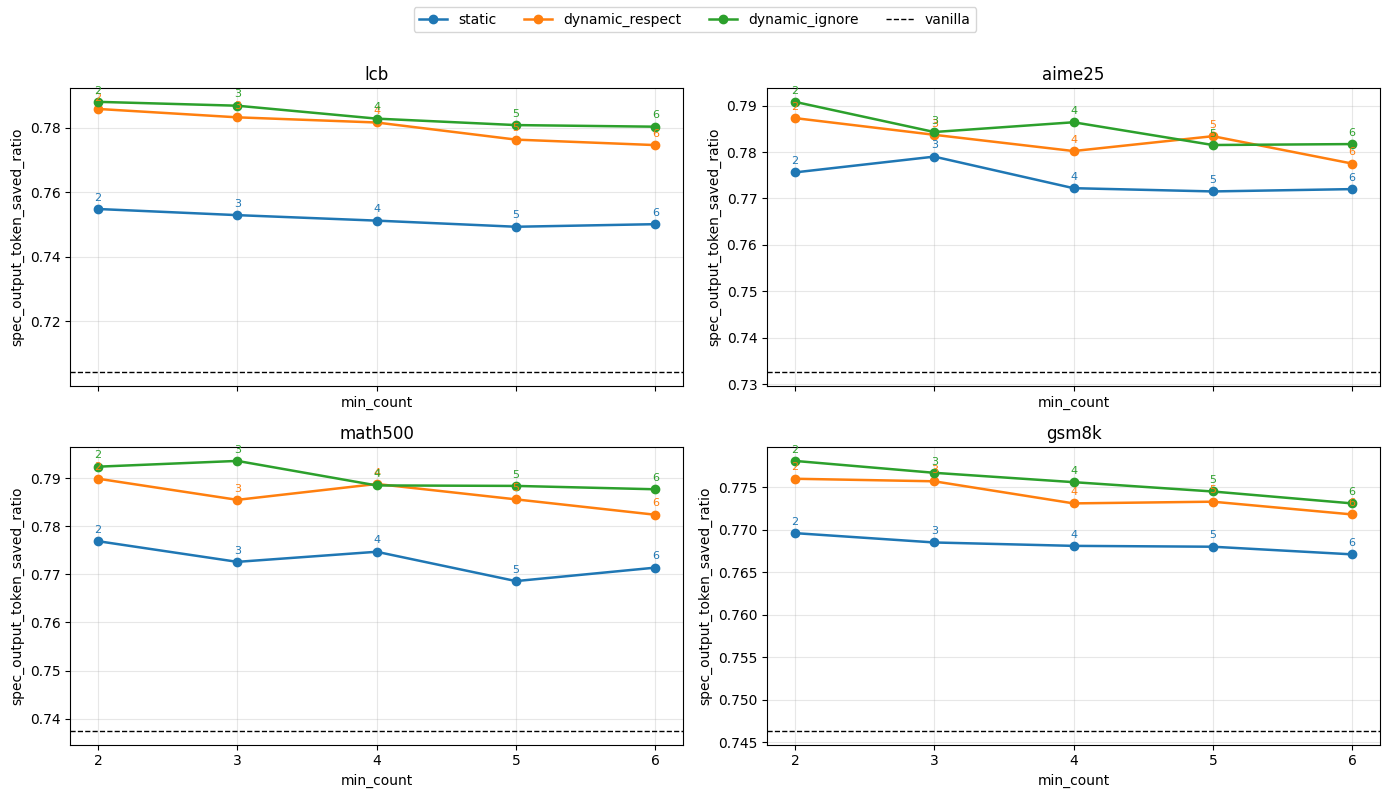

In [41]:
plot_metric_grid("spec_success_rate", "spec_success_rate", baseline_metric="spec_success_rate")
plt.show()

plot_metric_grid("accept_length", "aggregate_accept_length", baseline_metric="accept_length")
plt.show()

plot_metric_grid("spec_saved_ratio", "spec_output_token_saved_ratio", baseline_metric="spec_saved_ratio")
plt.show()

## Throughput And Speedup

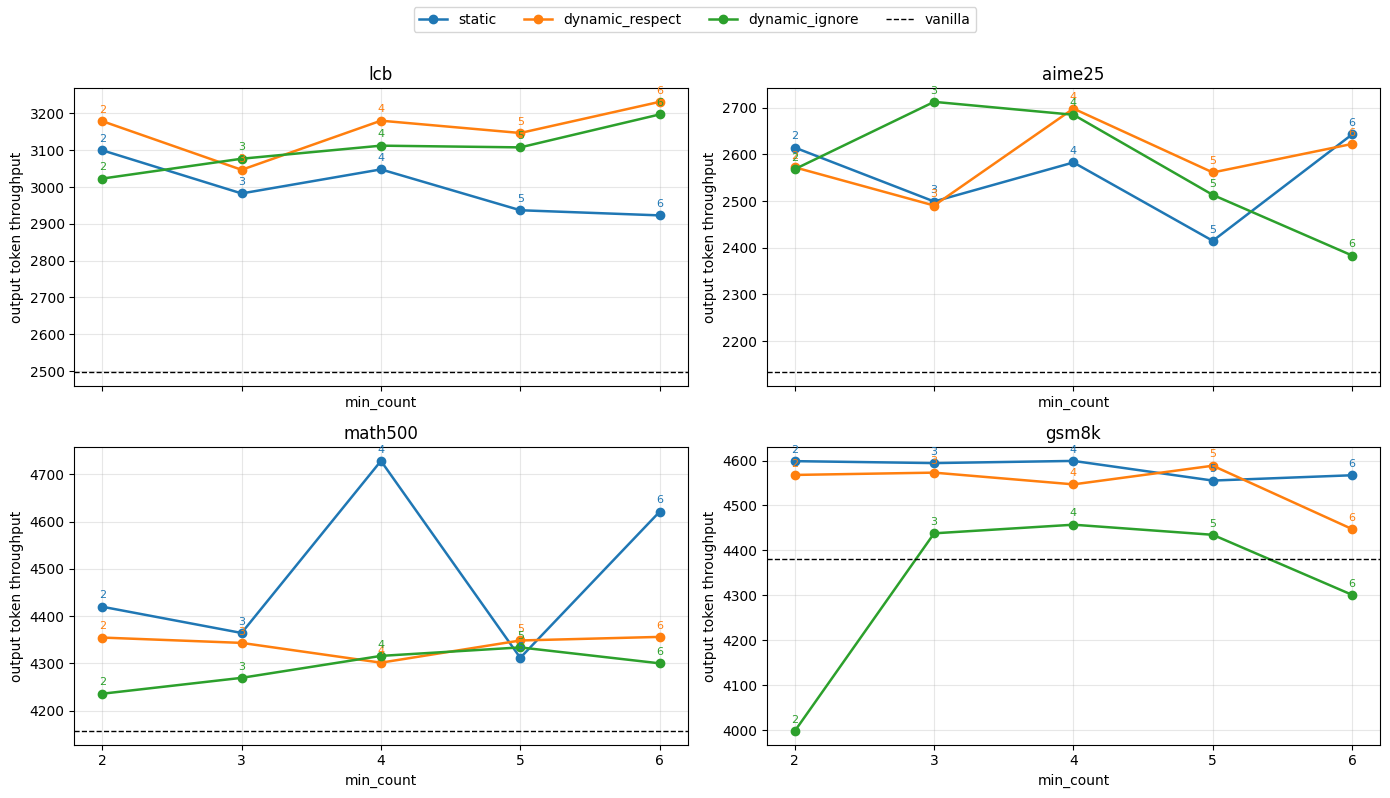

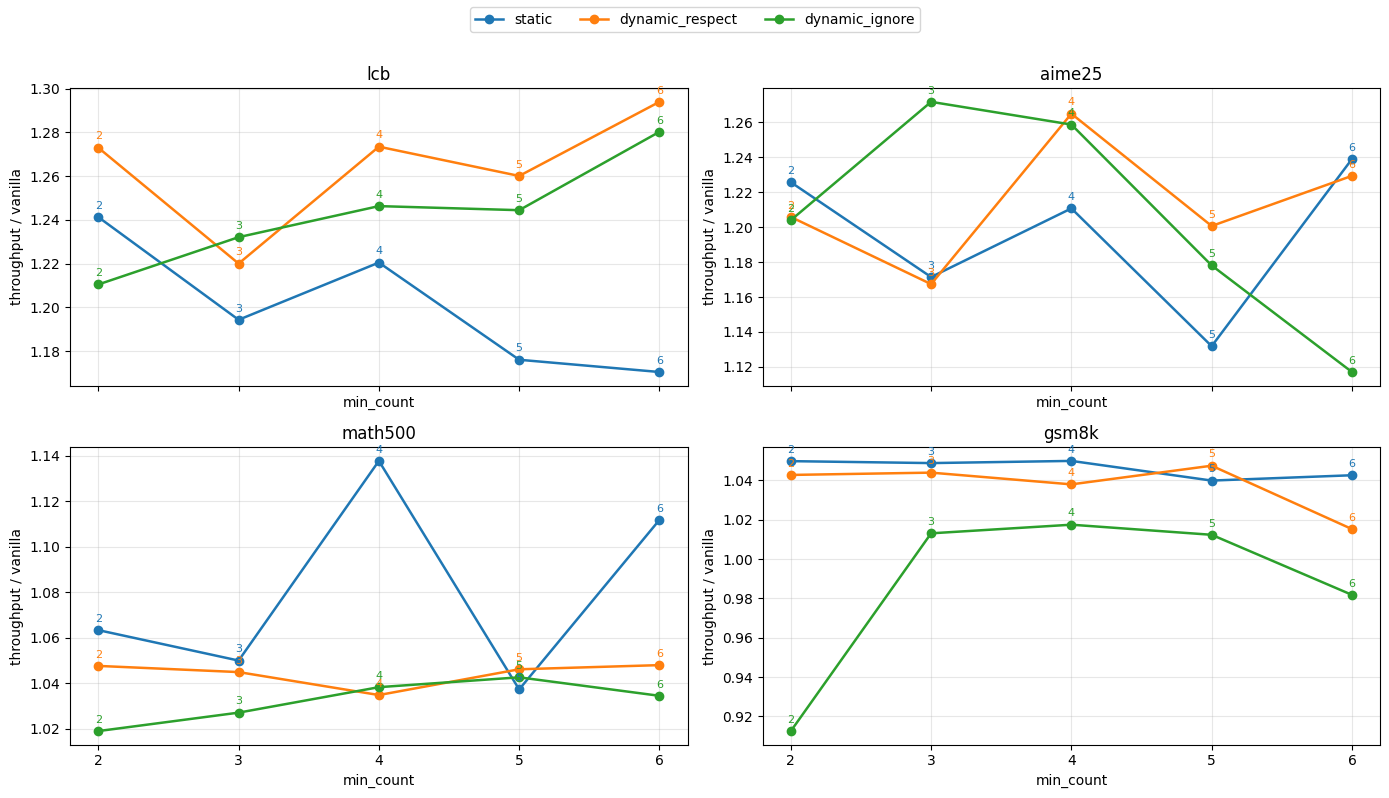

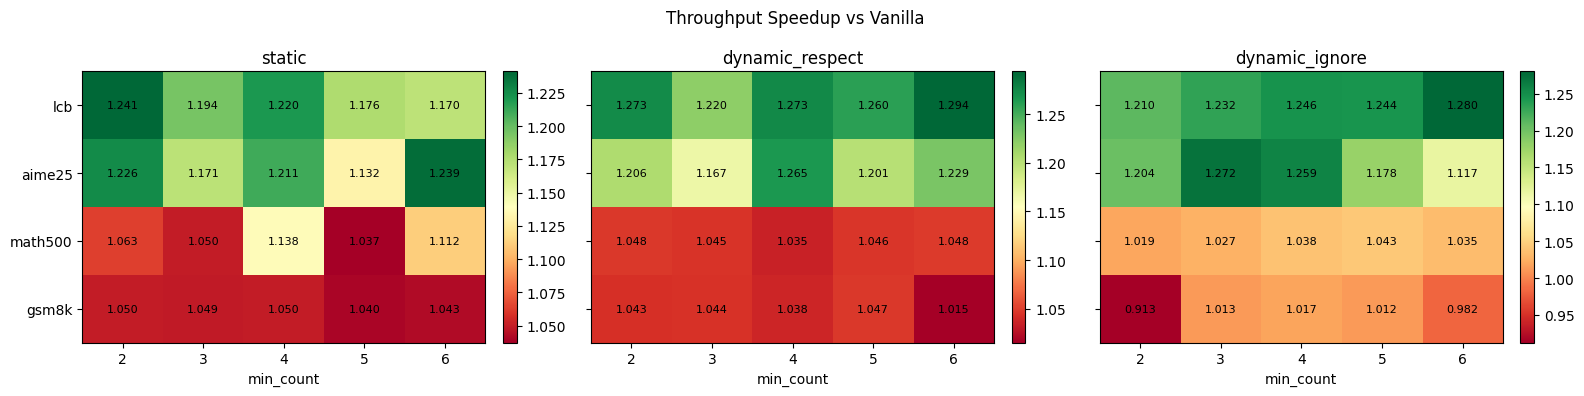

In [42]:
plot_metric_grid("throughput", "output token throughput", baseline_metric="throughput")
plt.show()

plot_metric_grid("throughput_speedup_vs_vanilla", "throughput / vanilla", include_zero_line=False)
plt.show()

heatmap_metric("throughput_speedup_vs_vanilla", "Throughput Speedup vs Vanilla")
plt.show()

## CSD Activity

`csd_lookup_hit_ct` and `csd_forced_accept_ct` are zero for vanilla. The forced-per-lookup ratio is useful for checking whether a larger table mainly increases lookups or also increases actual force accepts.

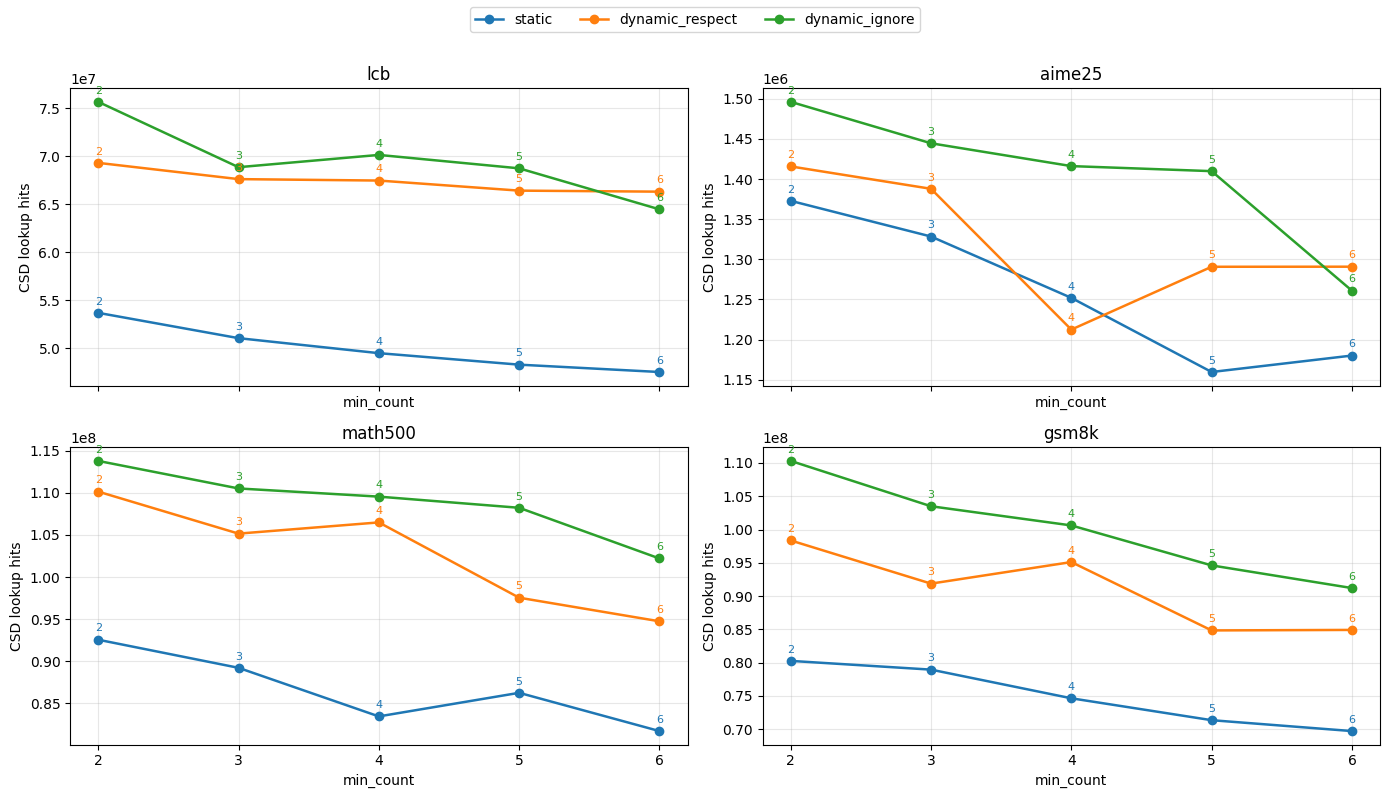

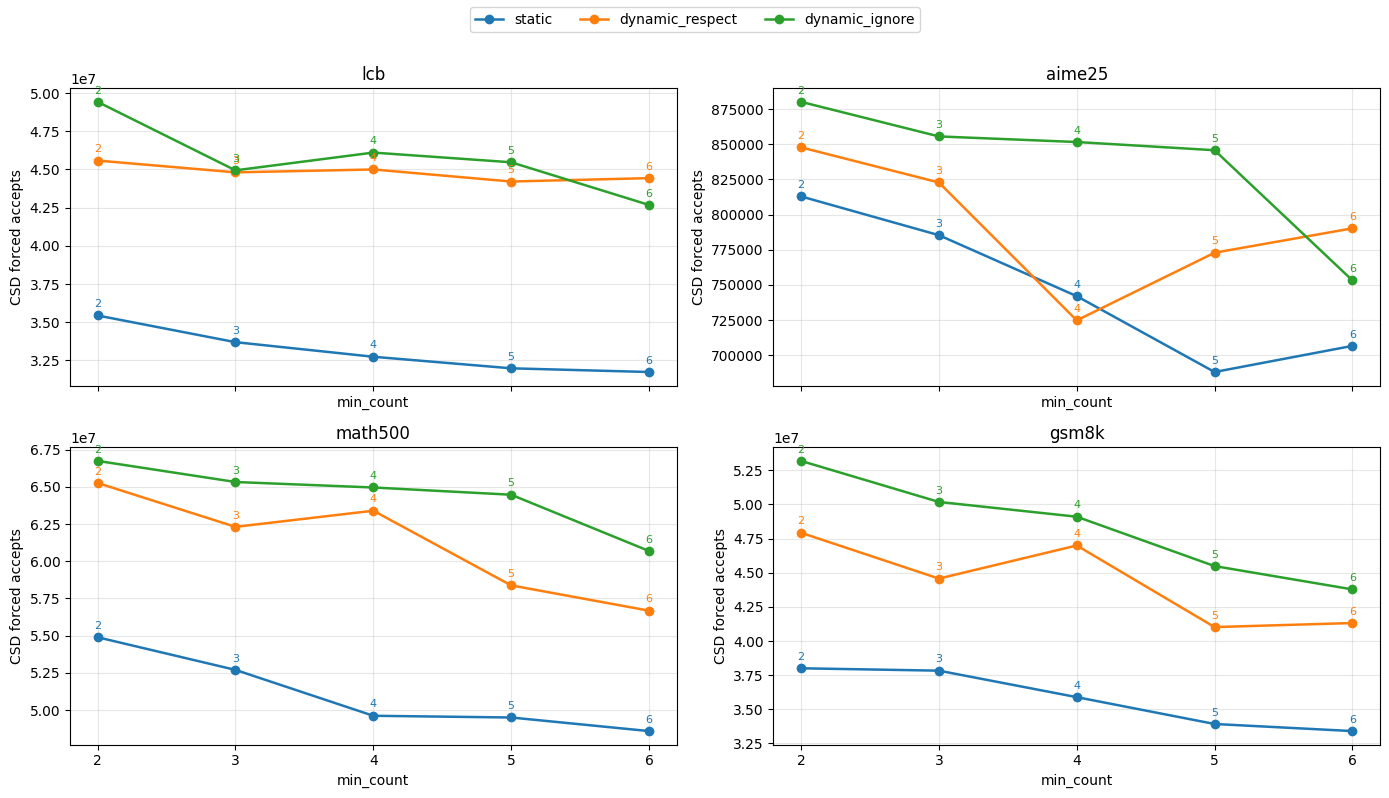

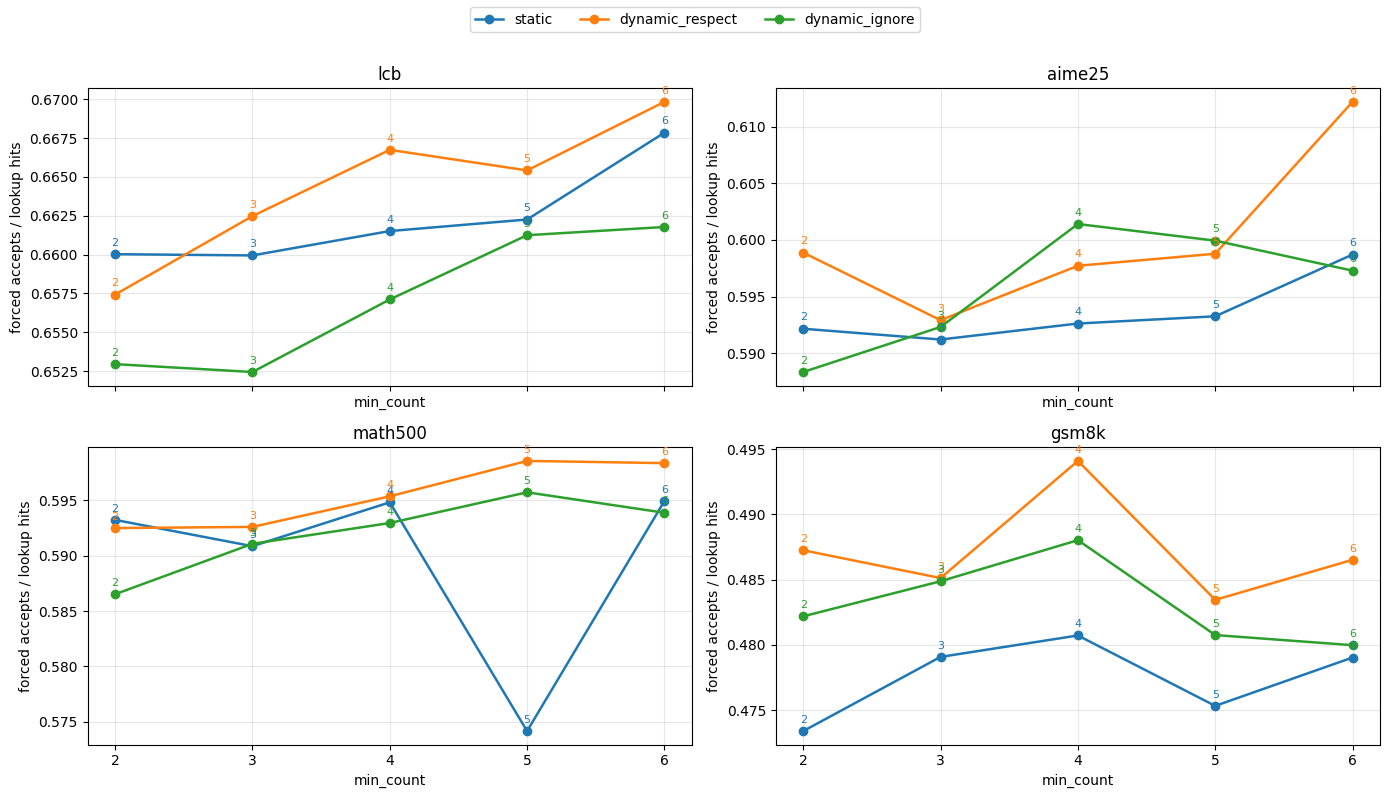

In [43]:
plot_metric_grid("csd_lookup_hit_ct", "CSD lookup hits", baseline_metric=None)
plt.show()

plot_metric_grid("csd_forced_accept_ct", "CSD forced accepts", baseline_metric=None)
plt.show()

plot_metric_grid("csd_force_per_lookup", "forced accepts / lookup hits", baseline_metric=None)
plt.show()

## Legacy Frequency/Top-K Comparison

Compare against the earlier decoding-comparison result:

`benchmark/csd/runs/lighteval_csd_decoding_comparison_sweep/20260526_014945/results/csd_decoding_comparison_sweep.jsonl`

That file predates the explicit key-selection-strategy field. From its config it is the legacy frequency strategy with `freq_threshold=6`, static plain table runs over `prob_ratio in {0.01, 0.1, 0.3}`, and dynamic plain-table top-keep runs with `top_keep in {5000, 15000}`. The plots below focus on speculative success rate and throughput.

In [44]:
LEGACY_RESULT_FILE = REPO_ROOT / "benchmark/csd/runs/lighteval_csd_decoding_comparison_sweep/20260526_014945/results/csd_decoding_comparison_sweep.jsonl"

def parse_legacy_rows(path: Path) -> pd.DataFrame:
    legacy_records = []
    with path.open() as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            other = row.get("other") or {}
            csd = other.get("csd") or {}
            server = other.get("server_config") or {}
            task = row.get("task")
            tag = other.get("run_tag", "")
            method = method_from_tag(tag, task)
            prob_ratio = csd.get("prob_ratio") or server.get("speculative_csd_prob_ratio")
            top_keep = csd.get("rebuild_top_keep") or server.get("speculative_csd_rebuild_top_keep")
            freq = csd.get("freq_threshold") or server.get("speculative_csd_freq_threshold")
            dynamic = bool(csd.get("dynamic_update"))
            if method == "baseline":
                family = "legacy_baseline"
                config_label = "baseline"
            elif method == "vanilla":
                family = "vanilla"
                config_label = "vanilla"
            elif method == "csd_plain_table_static":
                family = "legacy_static_freq6"
                config_label = f"r={prob_ratio}"
            elif method == "csd_plain_table_top5":
                family = f"legacy_dynamic_top{int(top_keep)}"
                config_label = f"r={prob_ratio},top={int(top_keep)}"
            else:
                family = method
                config_label = tag
            legacy_records.append({
                "source": "legacy_frequency",
                "task": task,
                "task_short": short_task(task),
                "family": family,
                "method": method,
                "config_label": config_label,
                "prob_ratio": prob_ratio,
                "top_keep": top_keep,
                "min_count": freq,
                "dynamic_update": dynamic,
                "accuracy": row.get("accuracy"),
                "spec_success_rate": row.get("spec_success_rate"),
                "throughput": row.get("throughput"),
                "accept_length": row.get("aggregate_accept_length"),
                "spec_saved_ratio": row.get("spec_output_token_saved_ratio"),
                "csd_lookup_hit_ct": row.get("csd_lookup_hit_ct") or 0,
                "csd_forced_accept_ct": row.get("csd_forced_accept_ct") or 0,
                "run_tag": tag,
            })
    return pd.DataFrame(legacy_records)

legacy_df = parse_legacy_rows(LEGACY_RESULT_FILE)

current_compare = df.copy()
current_compare["source"] = "above_uniform_share"
current_compare["family"] = current_compare["variant"].astype(str).map({
    "vanilla": "vanilla",
    "static": "above_static",
    "dynamic_respect": "above_dynamic_respect",
    "dynamic_ignore": "above_dynamic_ignore",
})
current_compare["config_label"] = current_compare.apply(
    lambda r: "vanilla" if r["variant"] == "vanilla" else f"min={int(r['min_count'])}",
    axis=1,
)
current_compare["prob_ratio"] = None
current_compare["top_keep"] = None

compare_cols = [
    "source", "task", "task_short", "family", "method", "config_label",
    "prob_ratio", "top_keep", "min_count", "dynamic_update", "accuracy",
    "spec_success_rate", "throughput", "accept_length", "spec_saved_ratio",
    "csd_lookup_hit_ct", "csd_forced_accept_ct", "run_tag",
]
compare_df = pd.concat([
    legacy_df[compare_cols],
    current_compare[compare_cols],
], ignore_index=True)

for col in ["accuracy", "spec_success_rate", "throughput", "accept_length", "spec_saved_ratio", "csd_lookup_hit_ct", "csd_forced_accept_ct"]:
    compare_df[col] = pd.to_numeric(compare_df[col], errors="coerce")

print("LEGACY_RESULT_FILE:", LEGACY_RESULT_FILE)
display(legacy_df.groupby(["task_short", "family"], observed=False).size().unstack(fill_value=0))
display(compare_df.head())

LEGACY_RESULT_FILE: /root/sglang/benchmark/csd/runs/lighteval_csd_decoding_comparison_sweep/20260526_014945/results/csd_decoding_comparison_sweep.jsonl


family,legacy_baseline,legacy_dynamic_top15000,legacy_dynamic_top5000,legacy_static_freq6,vanilla
task_short,,,,,
aime25,1,3,3,3,1
gsm8k,1,3,3,3,1
lcb,1,3,3,3,1
math500,1,3,3,3,1


,source,task,task_short,family,method,config_label,prob_ratio,top_keep,min_count,dynamic_update,accuracy,spec_success_rate,throughput,accept_length,spec_saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct,run_tag
0,legacy_frequency,lcb:codegeneration_v6|0,lcb,legacy_baseline,baseline,baseline,NaN,NaN,NaN,False,0.742857,0.0000,1683.366,0.0000,0.0000,0,0,baseline_lcb_recommended_steps5_topk1_draft5_f...
1,legacy_frequency,aime25|0,aime25,legacy_baseline,baseline,baseline,NaN,NaN,NaN,False,0.866667,0.0000,1274.975,0.0000,0.0000,0,0,baseline_aime25_recommended_steps5_topk1_draft...
2,legacy_frequency,math_500|0,math500,legacy_baseline,baseline,baseline,NaN,NaN,NaN,False,0.858000,0.0000,3176.027,0.0000,0.0000,0,0,baseline_math500_recommended_steps5_topk1_draf...
3,legacy_frequency,gsm8k|0,gsm8k,legacy_baseline,baseline,baseline,NaN,NaN,NaN,False,0.886277,0.0000,3795.452,0.0000,0.0000,0,0,baseline_gsm8k_recommended_steps5_topk1_draft5...
4,legacy_frequency,lcb:codegeneration_v6|0,lcb,vanilla,vanilla,vanilla,NaN,NaN,NaN,False,0.714286,0.4764,2512.465,3.3821,0.7043,0,0,vanilla_lcb_recommended_steps5_topk1_draft5_fr...


In [45]:
above_families = ["above_static", "above_dynamic_respect", "above_dynamic_ignore"]
FIXED_ABOVE_MIN_COUNT = 6

# Use the same-run vanilla EAGLE accuracy as a reference line. The focused plot
# below intentionally fixes above-uniform to min_count=6 for every task.
vanilla_source = compare_df[
    (compare_df["family"] == "vanilla")
    & (compare_df["source"] == "above_uniform_share")
].copy()
vanilla_accuracy = (
    vanilla_source
    .drop_duplicates("task_short")
    .set_index("task_short")["accuracy"]
)
compare_df["vanilla_accuracy"] = compare_df["task_short"].map(vanilla_accuracy)
compare_df["accuracy_ok"] = compare_df["accuracy"] >= compare_df["vanilla_accuracy"]

legacy_final = compare_df[
    (compare_df["family"] == "legacy_dynamic_top15000")
    & (compare_df["prob_ratio"] == 0.3)
].copy()
legacy_final["compare_label"] = "legacy_r0.3_top15000"

vanilla_rows = vanilla_source.copy()
vanilla_rows["compare_label"] = "vanilla"

above_min6 = compare_df[
    compare_df["family"].isin(above_families)
    & (compare_df["min_count"] == FIXED_ABOVE_MIN_COUNT)
].copy()
above_min6["compare_label"] = above_min6["family"].map({
    "above_static": "above_static_min6",
    "above_dynamic_respect": "above_dynamic_respect_min6",
    "above_dynamic_ignore": "above_dynamic_ignore_min6",
})

focused_min6 = pd.concat([vanilla_rows, legacy_final, above_min6], ignore_index=True)
focused_labels = [
    "vanilla",
    "legacy_r0.3_top15000",
    "above_static_min6",
    "above_dynamic_respect_min6",
    "above_dynamic_ignore_min6",
]
focused_min6["task_short"] = pd.Categorical(focused_min6["task_short"], categories=task_order, ordered=True)
focused_min6["compare_label"] = pd.Categorical(focused_min6["compare_label"], categories=focused_labels, ordered=True)
focused_min6 = focused_min6.sort_values(["task_short", "compare_label"])

show_cols = [
    "task_short", "compare_label", "family", "config_label", "accuracy", "vanilla_accuracy", "accuracy_ok",
    "spec_success_rate", "throughput", "accept_length", "spec_saved_ratio",
    "csd_lookup_hit_ct", "csd_forced_accept_ct",
]

print("Focused comparison: fixed above-uniform min_count=6 for every task")
display(focused_min6[show_cols])

print("AIME25 fixed min_count=6 rows")
display(
    focused_min6[
        (focused_min6["task_short"].astype(str) == "aime25")
        & (focused_min6["compare_label"].astype(str).str.contains("above_"))
    ][show_cols]
)

spec_pivot = focused_min6.pivot_table(index="task_short", columns="compare_label", values="spec_success_rate", observed=False)
throughput_pivot = focused_min6.pivot_table(index="task_short", columns="compare_label", values="throughput", observed=False)
print("Spec success delta: above min=6 variants - legacy r=0.3/top=15000")
display(spec_pivot[["above_static_min6", "above_dynamic_respect_min6", "above_dynamic_ignore_min6"]].sub(spec_pivot["legacy_r0.3_top15000"], axis=0))
print("Throughput delta: above min=6 variants - legacy r=0.3/top=15000")
display(throughput_pivot[["above_static_min6", "above_dynamic_respect_min6", "above_dynamic_ignore_min6"]].sub(throughput_pivot["legacy_r0.3_top15000"], axis=0))




Focused comparison: fixed above-uniform min_count=6 for every task


,task_short,compare_label,family,config_label,accuracy,vanilla_accuracy,accuracy_ok,spec_success_rate,throughput,accept_length,spec_saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct
0,lcb,vanilla,vanilla,vanilla,0.714286,NaN,NaN,0.4764,2497.427,3.3821,0.7043,0,0
4,lcb,legacy_r0.3_top15000,legacy_dynamic_top15000,"r=0.3,top=15000",0.742857,0.714286,True,0.6758,3166.109,4.3789,0.7716,61205861,41034040
8,lcb,above_static_min6,above_static,min=6,0.714286,0.714286,True,0.6005,2923.075,4.0023,0.7501,47532438,31744496
9,lcb,above_dynamic_respect_min6,above_dynamic_respect,min=6,0.731429,0.714286,True,0.6872,3231.660,4.4361,0.7746,66326484,44427869
10,lcb,above_dynamic_ignore_min6,above_dynamic_ignore,min=6,0.708571,0.714286,False,0.7102,3197.415,4.5510,0.7803,64484284,42674015
1,aime25,vanilla,vanilla,vanilla,0.900000,NaN,NaN,0.5479,2133.482,3.7397,0.7326,0,0
5,aime25,legacy_r0.3_top15000,legacy_dynamic_top15000,"r=0.3,top=15000",0.933333,0.900000,True,0.6920,2841.047,4.4599,0.7758,1265865,759875
11,aime25,above_static_min6,above_static,min=6,0.900000,0.900000,True,0.6771,2643.043,4.3855,0.7720,1180116,706547
12,aime25,above_dynamic_respect_min6,above_dynamic_respect,min=6,0.900000,0.900000,True,0.6990,2622.578,4.4952,0.7775,1290804,790220
13,aime25,above_dynamic_ignore_min6,above_dynamic_ignore,min=6,0.900000,0.900000,True,0.7162,2383.290,4.5808,0.7817,1260924,753136


AIME25 fixed min_count=6 rows


,task_short,compare_label,family,config_label,accuracy,vanilla_accuracy,accuracy_ok,spec_success_rate,throughput,accept_length,spec_saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct
11,aime25,above_static_min6,above_static,min=6,0.9,0.9,True,0.6771,2643.043,4.3855,0.7720,1180116,706547
12,aime25,above_dynamic_respect_min6,above_dynamic_respect,min=6,0.9,0.9,True,0.6990,2622.578,4.4952,0.7775,1290804,790220
13,aime25,above_dynamic_ignore_min6,above_dynamic_ignore,min=6,0.9,0.9,True,0.7162,2383.290,4.5808,0.7817,1260924,753136


Spec success delta: above min=6 variants - legacy r=0.3/top=15000


compare_label,above_static_min6,above_dynamic_respect_min6,above_dynamic_ignore_min6
task_short,,,
lcb,-0.0753,0.0114,0.0344
aime25,-0.0149,0.0070,0.0242
math500,-0.0614,-0.0172,0.0058
gsm8k,-0.0151,0.0026,0.0076


Throughput delta: above min=6 variants - legacy r=0.3/top=15000


compare_label,above_static_min6,above_dynamic_respect_min6,above_dynamic_ignore_min6
task_short,,,
lcb,-243.034,65.551,31.306
aime25,-198.004,-218.469,-457.757
math500,107.079,-157.967,-213.946
gsm8k,60.576,-59.251,-205.700


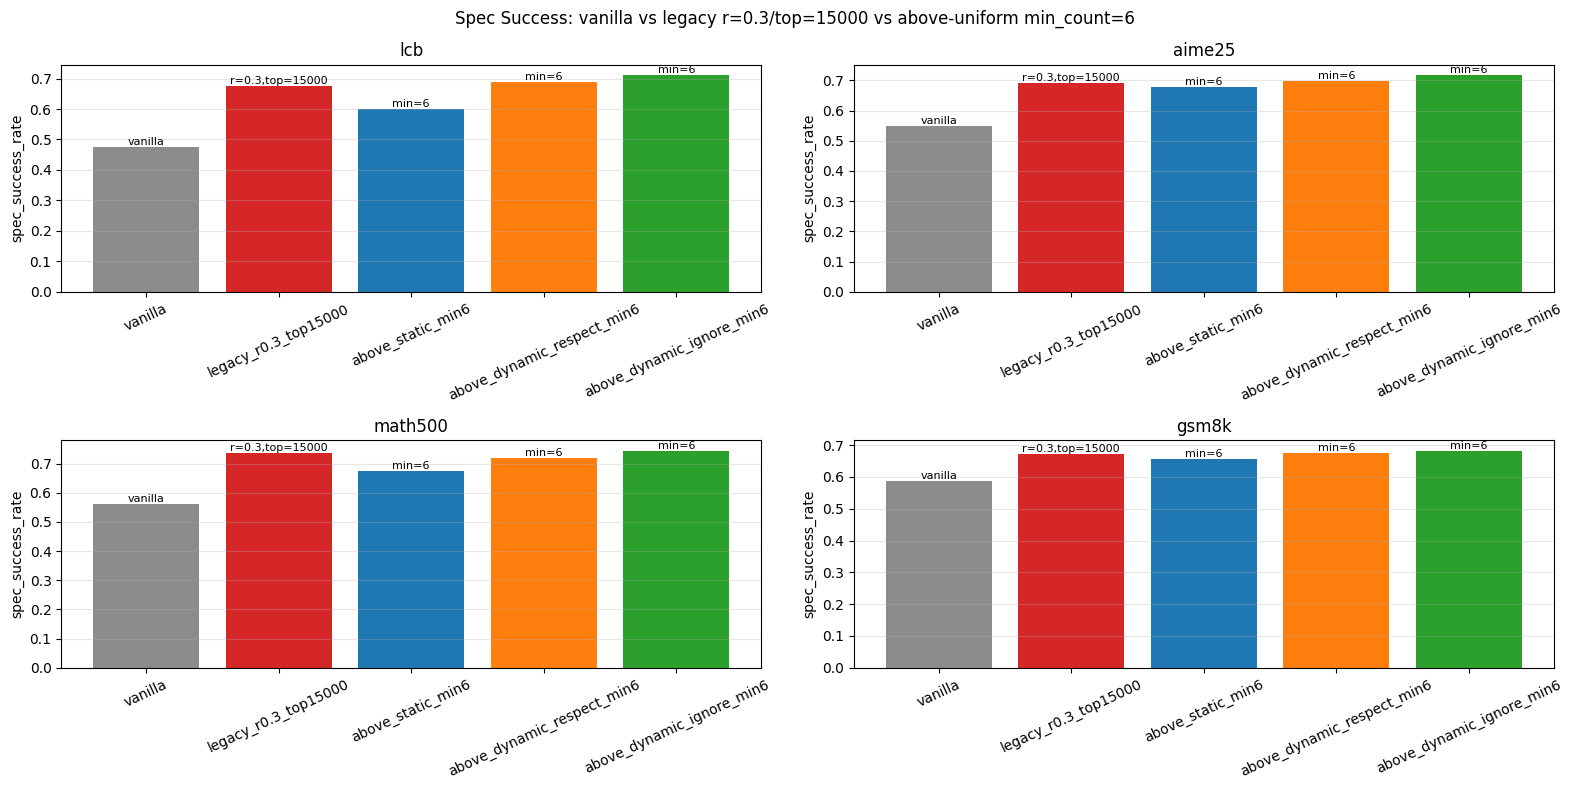

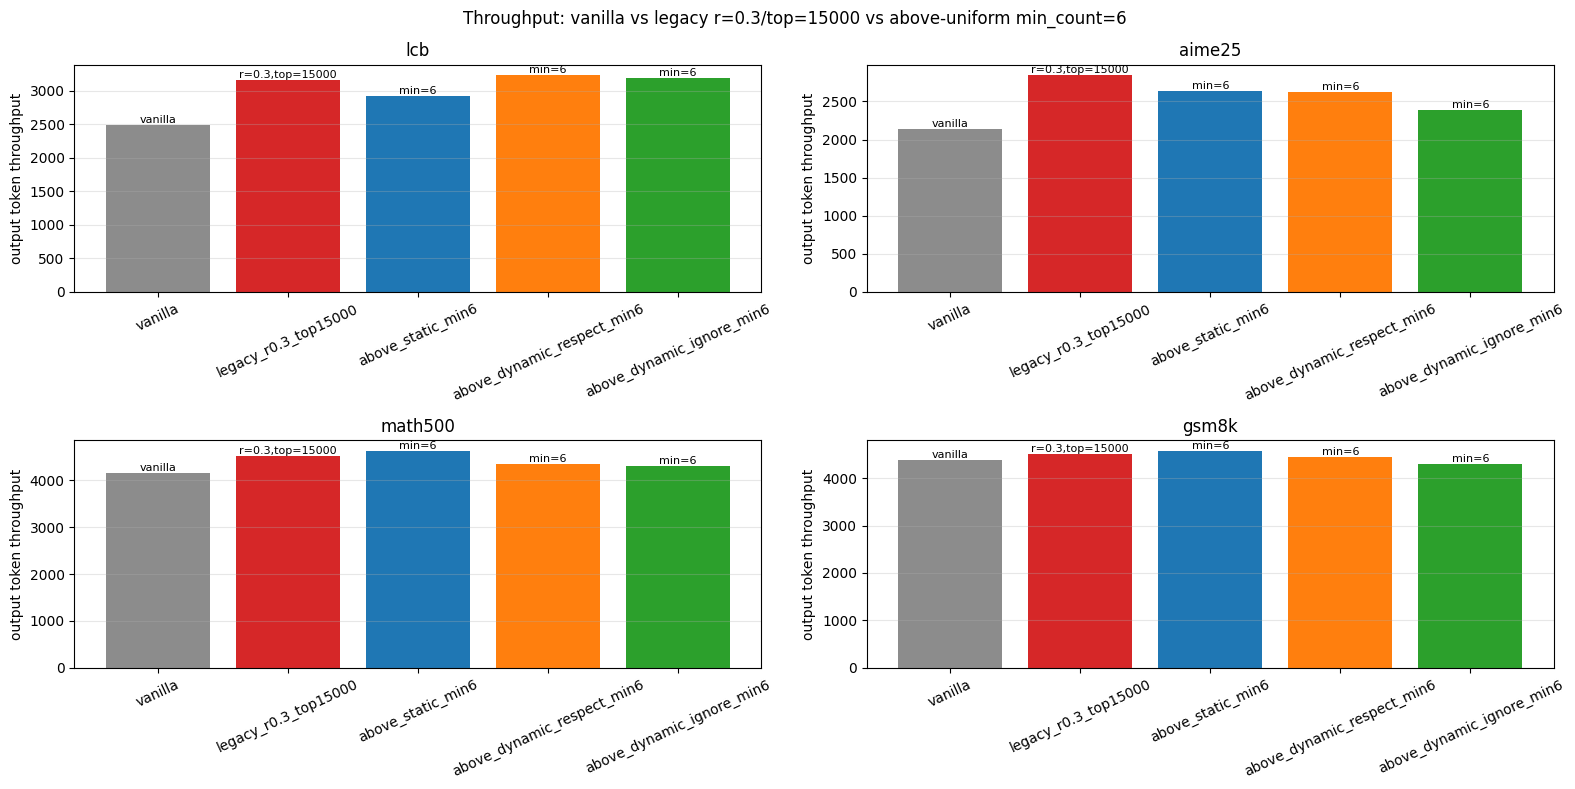

,variant,min_count,accuracy,spec_success_rate,throughput
17,static,2.0,0.866667,0.6912,2614.803
18,static,3.0,0.833333,0.7050,2499.129
19,static,4.0,0.933333,0.6781,2582.866
20,static,5.0,0.900000,0.6752,2414.796
21,static,6.0,0.900000,0.6771,2643.043
22,dynamic_respect,2.0,0.866667,0.7403,2572.448
23,dynamic_respect,3.0,0.900000,0.7245,2490.482
24,dynamic_respect,4.0,0.866667,0.7098,2698.368
25,dynamic_respect,5.0,0.866667,0.7231,2561.413
26,dynamic_respect,6.0,0.900000,0.6990,2622.578


In [46]:
def plot_focused_bars(frame: pd.DataFrame, metric: str, title: str, ylabel: str):
    labels = [
        "vanilla",
        "legacy_r0.3_top15000",
        "above_static_min6",
        "above_dynamic_respect_min6",
        "above_dynamic_ignore_min6",
    ]
    colors = ["0.55", "tab:red", "tab:blue", "tab:orange", "tab:green"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=False)
    axes = axes.ravel()
    for ax, task in zip(axes, task_order):
        sub = frame[frame["task_short"].astype(str) == task].set_index("compare_label").reindex(labels)
        bars = ax.bar(labels, sub[metric], color=colors)
        ax.set_title(task)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.3)
        for bar, (_, row) in zip(bars, sub.iterrows()):
            label = row["config_label"]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha="center",
                va="bottom",
                fontsize=8,
            )
    fig.suptitle(title)
    fig.tight_layout()
    return fig

plot_focused_bars(
    focused_min6,
    "spec_success_rate",
    "Spec Success: vanilla vs legacy r=0.3/top=15000 vs above-uniform min_count=6",
    "spec_success_rate",
)
plt.show()

plot_focused_bars(
    focused_min6,
    "throughput",
    "Throughput: vanilla vs legacy r=0.3/top=15000 vs above-uniform min_count=6",
    "output token throughput",
)
plt.show()

# Full AIME detail: all min_count values remain visible, including min_count=6.
aime_detail = df[(df["task_short"].astype(str) == "aime25") & (df["variant"].astype(str) != "vanilla")].sort_values(["variant", "min_count"])
display(aime_detail[["variant", "min_count", "accuracy", "spec_success_rate", "throughput"]])



## Export Compact CSV

Optional: write a compact CSV next to the JSONL for later plotting or paper tables.

In [47]:
EXPORT_CSV = RESULT_FILE.with_name("csd_above_uniform_share_summary.csv")
df[summary_cols + ["strategy", "dynamic_update", "ignore_prob_ratio", "run_tag"]].to_csv(EXPORT_CSV, index=False)
EXPORT_CSV

PosixPath('/root/sglang/benchmark/csd/runs/lighteval_csd_above_uniform_share/20260605_182153/results/csd_above_uniform_share_summary.csv')